# Übung 9

**Gruppenname:**

*TKKR*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

**Hinweis zu Jupyter Notebook**
* Wenn Sie eine Zelle teilen wollen (um zum Beispiel direkt unter einer Aufgabenstellung Ihre Lösung zu schreiben), dann können Sie im Edit-Modus den Cursor an die Stelle platzieren, an der Sie die Zelle teilen wollen. Drücken Sie dann `Strg+Shift+Minus`, um die Zelle an der Stelle des Cursors zu teilen.
* Wenn Sie zwei übereinander stehende Zellen vereinigen wollen, gehen Sie in den Edit-Modus und markieren mit gehaltener Shift-Taste und den Cursortasten die Zellen, die Sie vereinigen wollen. Drücken Sie dann `Shift+m`.

### 9.1 Weight Decay Regularisierung
In dieser Übung untersuchen wir, woher der Name *Weight Decay* ("Gewichtszerfall") für die in der Vorlesung vorgestellte Regularisierungstechnik stammt.

Betrachten Sie den *erweiterten Fehler*

$$E_\text{aug}(\mathbf{w}) = E_\text{in}(\mathbf{w}) + \lambda^\prime \mathbf{w}^\text{T}\mathbf{w}$$

wo wir $\lambda^\prime = \frac{\lambda}{N}$ definiert haben, um uns etwas Schreibarbeit zu sparen. Wir nehmen an, dass $E_\text{in}$ differenzierbar ist, und betrachten den Gradientenabstieg für den *erweiterten Fehler*.

**Ihre Aufgaben**

(1) Schlagen Sie in Vorlesung 7 nach, wie das Gewichtsupdate für den Gradientenabstieg mit fixierter Lernrate definiert ist.

$w(t+1)=w(t)- \eta \nabla E_\text{in}(w(t))$

(2) Zeigen Sie, dass gilt:
$$\mathbf{w}(t+1) = \underbrace{\left( 1-2\eta \lambda^\prime\right) \mathbf{w}(t)}_{\text{Gewichtszerfall}}-\eta \nabla E_\text{in}(\mathbf{w}(t))$$

Das Gewicht $\mathbf{w}(t)$ "zerfällt" also, bevor es für das Gewichtsupdate genutzt wird. Das ist der Grund, warum diese Regularisierungstechnik "weight decay" genannt wird.

$$w(t+1)=w(t)- \eta \nabla E_\text{aug}(w(t))=w(t+1)=w(t)- \eta \nabla (E_\text{in}(w(t)) + \lambda ' w^T w)$$
$$w(t+1)=w(t)-\eta \nabla E_\text{in}(w(t)) - \eta \cdot 2 \cdot \lambda' w(t)$$
$$w(t+1)=w(t)(1-\eta \cdot 2 \cdot \lambda' )-\eta \nabla E_\text{in}(w(t))$$

### 9.2 Weight Decay und lineare Regression


In dieser Übung werden wir *Weight Decay* für die lineare Regression implementieren und bei der Regression von Polynomen testen. Dazu werden wir lineare Regression mit *nonlinear feature transform* durchführen. Als Basis für die Feature Transformation nutzen wir die Legendre-Polynome, die Sie in der Vorlesung kennengelernt haben.

**Daten**
* Sie haben *N=5* Trainingsdatenpaare $(x_i, y_i)$ vorliegen, die durch eine Polynom 2ter Ordnung erzeugt wurden und mit Rauschen kontaminiert sind.
* Die Target Function (das Polynom 2ter Ordnung) habe ich Ihnen weiter unten implementiert, sodass Sie in dieser Übung keine externen Daten in Ihr Jupyter Notebook laden müssen. Wir nehmen wie immer an, dass wir die Target Function nicht kennen.
* Wir werden im Rahmen der Übung die Daten mit einem Polynom 4ter Ordnung approximieren und dabei Weight Decay einsetzen.

**Ihre Aufgaben**

(1) Ich habe für Sie ein Polynom 2ter Ordnung als Target-Function implementiert. Die 5 Trainingsdatenpunkte sind mit Rauschen kontaminiert. Führen Sie den untenstehenden Code aus und betrachten Sie die Visualisierung der Daten und der Target-Function.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

def random_sample(a, b, N, sorted=True):
    """Returns a random sample of size N drawn uniformly from the interval [a,b].

    The sample is sorted by default in ascending order.
    If sorted=False, this function returns the random sample unsorted.
    """
    if sorted:
        return np.sort(np.random.random_sample(size=N) * (b - a) + a)
    else:
        return np.random.random_sample(size=N) * (b - a) + a


def get_target_function(Qf, N, sigma):
    """Returns a target function of order Qf as well as training data.

    This function returns a target function of order Qf and noisy
    training data, where the noise is drawn from a standard normal
    distribution with standard deviation sigma.
    """

    # create unscaled Legendre polynom
    coefs = np.random.standard_normal(Qf + 1)
    unscaled_target = np.polynomial.Legendre(coefs)

    # create training data (x-values)
    x = random_sample(-1, 1, N)  # these random values are sorted to facilitate plotting

    # scale Legendre polynom
    factor = np.mean(np.power(unscaled_target(x), 2))
    scoefs = coefs / np.sqrt(factor)
    target = np.polynomial.Legendre(scoefs)

    # create training data (y-values). add noise
    y = target(x) + sigma * np.random.standard_normal(len(x))

    return x, y, target


# w_lin = (X^T*X)^(-1)*X^T*y
def lin_reg(x_old, y):
    """Linear regression.
    This function implements standard linear regression.
    Use your own implementation if desired.
    """
    x_old = x_old[:, np.newaxis]
    X = np.array([np.concatenate(([1], a)) for a in x_old])
    y = np.array(y)
    Xt = np.linalg.inv(np.dot(X.T, X))
    return np.dot(np.dot(Xt, X.T), y)

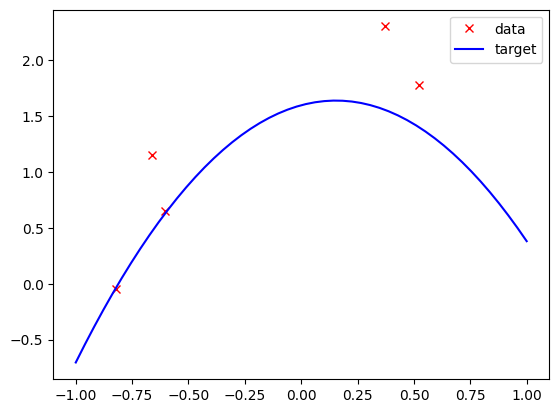

In [2]:
# obtain training data and target function
np.random.seed(10)  # use this seed so we all work with the same target function and data
x, y, target = get_target_function(2, 5, 0.5)

# visualize the data (and the target function as well)
xv = np.linspace(-1, 1, 50)
plt.plot(x, y, 'xr')
plt.plot(xv, target(xv), 'b-')
plt.legend(('data', 'target'))

(2) Schlagen Sie in den Folien der heutigen Vorlesung nach, wie *regularisierte Regression mit Weight Decay* durchgeführt wird (also wie $w_\text{reg}$ definiert ist).

$$\begin{array}{ccc} w_\text{reg}=\underset{w\in \mathbb{R}^{d+1}}{\text{arg min}} E_\text{in} (w) & \text{mit} & w^Tw \leq C \end{array}$$
$$w_\text{reg}=(Z^TZ+\lambda \mathbb{1})^{-1}Z^Ty$$

(3) Implementieren Sie *regularisierte Regression mit Weight Decay*, indem Sie entweder Ihren eigenen Code für lineare Regression aus einer alten Übung anpassen, oder indem Sie den angegebenen Code anpassen. Ihre Funktion nimmt die Features $\mathbf{x}$, die Labels $\mathbf{y}$ sowie den Regularisierungsparameter $\lambda$ entgegen und gibt $w_\text{reg}$ zurück.
* Hinweis: Wenn Sie den Code adaptieren, achten Sie unbedingt darauf, dass die erste Feature-Komponente (die Einsen) bereits in der Funktion hinzugefügt werden und daher nicht in den übergebenen Features enthalten sein dürfen. Daneben erwartet die Funktion die *N* Trainingsdaten in der Form (N, 1) statt (N,).

In [3]:
def lin_reg(X, y, lamb):
    XD = np.dot(np.linalg.inv(np.dot(X.T, X) + np.identity(X.shape[0]) * lamb), X.T)
    return np.dot(XD, y)

(4) Für die nonlinear feature transform nutzen wir als Basis die Legendre-Polynome.
 * Schlagen Sie zunächst in den Folien nach, wie die Legendre Polynome aussehen, auf welchem Interval sie definiert sind und wie diese in einer nonlinear feature transform genutzt werden (d.h. wie ein entsprechendes Hypothesenset definiert wird).
 * Die Legendre-Polynome finden Sie in `numpy.polynomial.legendre.Legendre.basis` implementiert. Schlagen Sie in der [Dokumentation](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.legendre.Legendre.basis.html) nach und visualisieren Sie testweise einmal $L_1(x)$ und $L_3(x)$ für $x\in [-1,1]$
 * Implementieren Sie eine Feature Transformation 4ter Ordnung, also $Q=4$. Ihre Funktion $\mathbf{z} = \Phi_4(\mathbf{x})$ nimmt einen $\mathbf{x}$ Vektor der Größe $(N\times 1)$ entgegen (*N* ist die Anzahl der Trainingsdatenpunkte) und gibt die transformierten Features $\mathbf{z}$ der Größe $(N\times 5)$ zurückgibt. Nutzen Sie `numpy.polynomial.legendre.Legendre.basis` für Ihre Implementierung. **Frage:** Warum gibt Ihre Transformation 4ter Ordnung für jedes ursprüngliche Feature *5* transformierte Features zurück?

In [4]:
from numpy.polynomial.legendre import Legendre

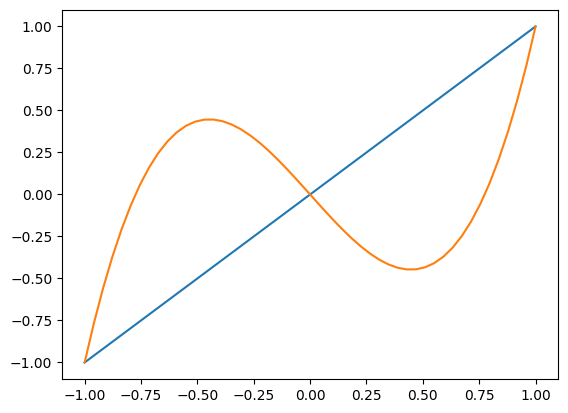

In [5]:
l1 = Legendre.basis(1)
l3 = Legendre.basis(3)

x_space = np.linspace(-1, 1)
plt.plot(x_space, l1(x_space))
plt.plot(x_space, l3(x_space))
plt.show()

In [6]:
def phi4(x: np.ndarray) -> np.ndarray:
    return np.c_[np.ones(x.shape), Legendre.basis(1)(x), Legendre.basis(2)(x), Legendre.basis(3)(x), Legendre.basis(4)(x)]

**Antwort**: z beginnt mit dem Bias, also einer Spalte mit Einsen.

(5) Transformieren Sie die Trainingsdaten mithilfe Ihrer nonlinear feature transform und erhalten Sie mit $\lambda=0.005$ mittels Ihrer Implementierung der regularisierten Regression den Vektor $\mathbf{w}_\text{reg}$ (dieser Vektor sollte 5 Komponenten aufweisen). Im nächsten Schritt kümmern wir uns um die Visualisierung.

In [7]:
X = phi4(x[:, np.newaxis])
lamba = 0.005
w_reg = lin_reg(X, y, lamba)
print(w_reg.shape)

(5,)


(6) Visualisieren Sie das Polynom, das durch $\mathbf{w}_\text{reg}$ definiert wird:
* Erinnern Sie sich dazu daran, dass wir uns durch die feature transform im Feature-Raum $\mathcal{Z}$ befinden. Das bedeutet, dass der Vektor $\mathbf{w}_\text{reg}$ unser gefittetes Polynom in der Basis der Legendre-Polynome darstellt (wie auf den Folien der heutigen Vorlesung dargestellt).
* Sie können selbst eine Funktion schreiben, die das Polynom in der Basis der Legendre-Polynome mit den Koeffizienten $\mathbf{w}_\text{reg}$ darstellt **oder** Sie nutzen eine schon implementierte Funktion, die das für Sie erledigt. Schauen Sie dazu in die [Dokumentation](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.legendre.Legendre.html) von `numpy.polynomial.legendre.Legendre`.
* Erzeugen Sie einen Plot, der die Daten, die Target Function und das gefittete Polynom darstellt.

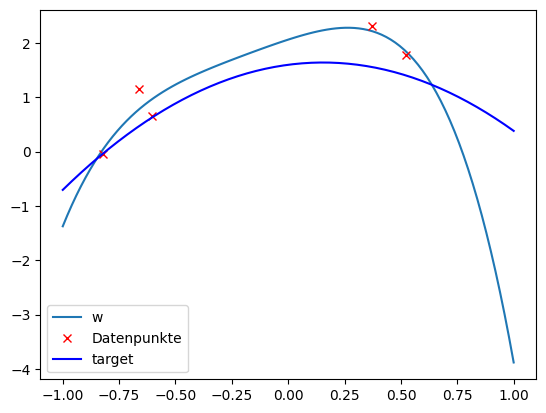

In [8]:
x_space, y_space = Legendre(w_reg).linspace()
xv = np.linspace(-1, 1, 50)
plt.plot(x_space, y_space, label="w")
plt.plot(x, y, 'xr', label="Datenpunkte")
plt.plot(xv, target(xv), 'b-', label="target")
plt.legend()
plt.show()

(7) Erstellen Sie nun eine Serie von Plots, in der jeder Plot die Daten, die Target Function und das gefittete Polynom darstellt. Die Target Function und die Daten bleiben dabei unverändert. Was Sie ändern ist die "Stärke" der Regularisierung. Erstellen Sie einzelne Plots für $\lambda\in\{ 0, 0.0001, 0.001, 0.01, 0.1, 1, 10\}$. Was beobachten Sie? (1-2 Sätze)

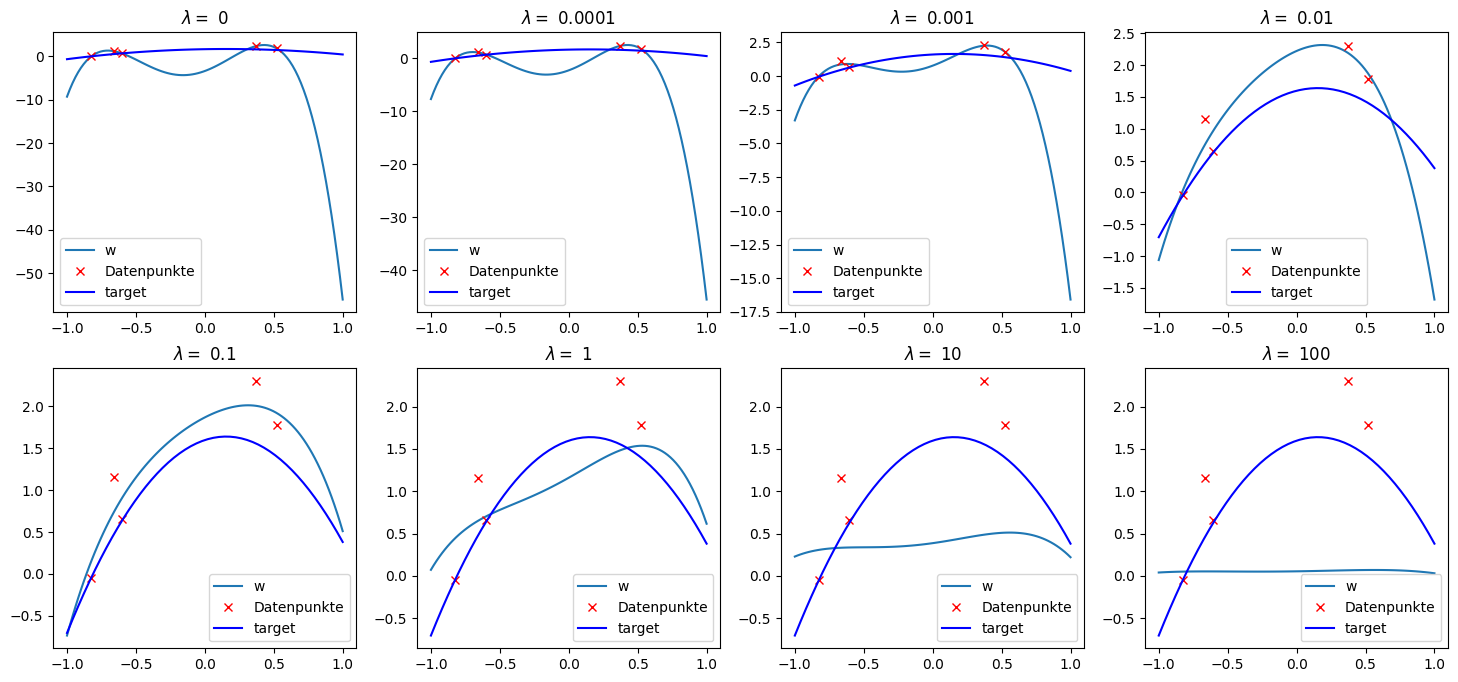

In [9]:
_, ax = plt.subplots(2, 4, figsize=(18, 8))
ax = ax.flatten()

for i, lamb in enumerate([0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]):
    w_lamb = lin_reg(X, y, lamb)
    x_space, y_space = Legendre(w_lamb).linspace()
    xv = np.linspace(-1, 1, 50)
    ax[i].plot(x_space, y_space, label="w")
    ax[i].plot(x, y, 'xr', label="Datenpunkte")
    ax[i].plot(xv, target(xv), 'b-', label="target")
    ax[i].set_title(f"$\\lambda =$ {lamb}")
    ax[i].legend()
plt.show()

(8) Welche Veränderung beobachten Sie in den Gewichten des Vektors $\mathbf{w}_\text{reg}$ aus Schritt (7), wenn Sie die Größe $\lambda$ von $0$ bis $10$ erhöhen? (1 Satz)

Je höher $\lambda$, desto flacher scheint w zu werden. Bei sehr hohen Werten für $\lambda$, wird r zur Gerade

### 9.3 Feature Engineering mittels PCA (Ziffernerkennung - Teil 2)

Sie haben in Übung 4.3 (Feature Engineering für die Erkennung handgeschriebener Ziffern) festgestellt, dass das Generieren von Merkmalen (Feature Engineering) für die Klassifikation der Zifferndaten durch den Pocket-Algorithmus nicht einfach war. Es gibt viele Methoden, um Features "herzustellen". In dieser Übung werden wir die Hauptkomponentenzerlegung (Principal Component Analysis, kurz: **PCA**) nutzen, um Features für die Klassifikation zu gewinnen. PCA ist eine typische Methode aus dem Unsupervised Learning. Im Gegensatz zum händischen Feature Engineering in Übung 4.3 haben Sie mit der PCA ein Werkzeug an der Hand, das Ihnen Features fast ohne Ihr Zutun generieren kann.

Wir werden beispielhaft mit dem Zifferndatensatz arbeiten, um Features zu erzeugen, mit der Sie die Ziffer "1" von den anderen Ziffern unterscheiden können.

* Ich nehme Sie in dieser Übung etwas mehr "an die Hand", damit Sie sich gut durch den Lernstoff arbeiten können.

**Ihre Aufgaben**

(1) Machen Sie sich erneut mit dem Zifferndatensatz vertraut, indem Sie die unten stehende Code-Zelle ausführen und folgende Fragen beantworten:

1. Wie viele Datenpunkte (Featurevektoren) enthält der Trainingsdatensatz?
2. Wie viele Features (= Anzahl der Featurevektorkomponenten) enthält jeder Datenpunkt?

Wir werden uns im Nachfolgenden allein auf die Trainingsdaten konzentrieren und den Testdatensatz nicht verwenden.

data dictionary keys:  dict_keys(['__header__', '__version__', '__globals__', 'train_data', 'train_targets', 'test_data', 'test_targets'])


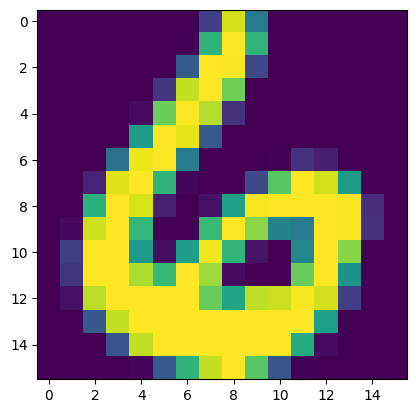

In [10]:
from io import BytesIO
import requests
from scipy.io import loadmat
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

# Wenn Sie offline arbeiten wollen, finden Sie die Datei
# zum Download hier: https://data.bialonski.de/ml/digits_dataset.mat
file = requests.get('https://data.bialonski.de/ml/digits_dataset.mat')
data = loadmat(BytesIO(file.content))

plt.imshow(np.reshape(data['train_data'][0], (16, 16)))
print('data dictionary keys: ', data.keys())

In [11]:
print(f"Der Datensatz enthält {data['train_data'].shape[0]} Datenpunkte mit jeweils {data['train_data'].shape[1]} Features.")

Der Datensatz enthält 7291 Datenpunkte mit jeweils 256 Features.


(2) Wir wollen die Ziffer "1" von allen anderen Ziffern unterscheiden. Erzeugen Sie daher einen Vektor `y`, dessen Vektorkomponenten jeweils den Wert "1" aufweisen, sofern der Datenpunkt die handgeschriebene Ziffer "1" darstellt, und "0" für alle anderen Ziffern.

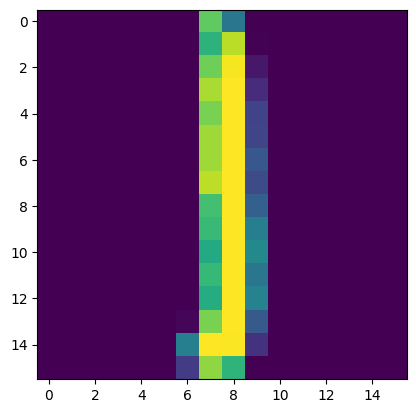

In [12]:
y = np.where(data['train_targets'] == 1, 1, 0)[0]
plt.imshow(np.reshape(data['train_data'][y == 1][0], (16, 16)))
plt.show()

(3) Nehmen Sie sich die Zusatzfolien aus der letzten Übung zur PCA zur Hand und schlagen Sie nach, mit welchen Schritten eine PCA durchgeführt wird. Listen Sie kurz diese Schritte auf.

1. Kovarianzmatrix generieren
2. Eigenwerte und -vektoren der Matrix berechnen
3. Proportion of Variance Explained berechnen und Achsen auswählen
4. Daten transformieren

(4) Normieren Sie zunächst Ihre Daten: Ihr Datensatz bestehe aus $N$ Datenpunkten, die jeweils aus einem Featurevektor mit $M$ Features (Merkmalen) bestehen. Sei $m$ der Index des Features. Ihre normierten Daten speichern Sie in dem Array `X` (N x M Matrix).

1. Normieren Sie Ihre Daten so, dass der Mittelwert jedes Features den Wert $0$ annimmt. Dazu bestimmen Sie für jedes Feature $m$ den Mittelwert über alle $N$ Datenpunkte, und ziehen diesen [Mittelwert](https://docs.scipy.org/doc/numpy/reference/generated/numpy.mean.html) von dem Feature $m$ ab. Dieser Schritt wird im Laborjargon auch "Demeaning" genannt.
2. Skalieren Sie Ihre Daten nach dem ersten Schritt so, dass die Standardabweichung für jedes Feature $m$ über alle $N$ Datenpunkte den Wert "1" annimmt. Dazu bestimmen Sie die [Standardabweichung](https://docs.scipy.org/doc/numpy/reference/generated/numpy.std.html) für jedes Feature $m$ über alle $N$ Datenpunkte, und dividieren jedes Feature $m$ durch seine Standardabweichung.

Schritte 1 und 2 werden auch [z-scoring](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.zscore.html) genannt. Es handelt sich um einen typischen Vorverarbeitungsschritt, der Ihnen in vielen Machine Learning Projekt begegnen wird.

In [13]:
from scipy.stats import zscore

In [14]:
X_scored = zscore(data["train_data"])

(5) Bestimmen Sie nun die Kovarianzmatrix $S$ aus Ihren normierten Daten

* Welche Dimensionen erwarten Sie für Ihre Kovarianzmatrix?
* [Bestimmen Sie](https://docs.scipy.org/doc/numpy/reference/generated/numpy.cov.html) die Kovarianzmatrix und stellen Sie sicher, dass Sie die richtigen Dimensionen aufweist.

In [15]:
S = np.cov(X_scored.T)
print(S.shape)

(256, 256)


(6) [Berechnen Sie die Eigenwerte](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eig.html) (Array: `eig_vals`) sowie assoziierten Eigenvektoren (`eig_vecs`) Ihrer Kovarianzmatrix $S$.

In [16]:
eigvals, eigvecs = np.linalg.eig(S)

(7) Ein typischer Fehler ist es, anzunehmen, dass Ihre Eigenwerte sortiert vorliegen. Dies ist im Allgemeinen *nicht* der Fall. Daher sortieren Sie bitte die Eigenwerte in absteigender Größe. Nutzen Sie dafür [diesen Befehl](https://docs.scipy.org/doc/numpy/reference/generated/numpy.argsort.html), um die Sortierung in eine separate Variable `idx` zu speichern, mit der Sie dann die Sortierung der Eigenwerte vornehmen.

* Beachten Sie, dass der Ihnen angegebene Befehl nicht in absteigender Reihenfolge (*descending order*) sortieren kann. Sortieren Sie also zunächst aufsteigend und kehren Sie dann die Reihenfolge im resultierenden Array um.
* Falls Sie glauben, dass Ihre Eigenwerte schon sortiert vorliegen, ohne dass Sie sortieren müssen, prüfen Sie dies nach, indem Sie sich die Variable `idx` anschauen.

In [17]:
idx = np.argsort(eigvals)[::-1]

eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

(8) Sortieren Sie nun die assoziierten Eigenvektoren, die Sie im Array `eig_vecs` gespeichert hatten.
* Beachten Sie: Die Eigenvektoren liegen als Spalten in `eigen_vecs` vor, *nicht* als Zeilen. Das Verwechseln von Zeilen und Spalten ist eine typische Fehlerquelle.
* Nutzen Sie `idx`, um die Spalten (also die Eigenvektoren) so zu sortieren, dass sie zu Ihren sortierten Eigenwerten passen. Dazu können Sie [Integer Array Indexing](https://numpy.org/doc/stable/user/basics.indexing.html#integer-array-indexing) einsetzen. Für Integer Array Indexing müssen Sie Ihr Array `idx` [in eine Python Liste umwandeln](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.tolist.html).

(9) Projizieren Sie Ihre normierten Daten auf die erste PCA-Komponente (d.h. auf die Komponente mit dem größten Eigenwert) und nennen Sie den resultierenden Vektor `x1`. Wiederholen Sie den Vorgang für die zweite PCA-Komponente und nennen Sie den resultierenden Vektor `x2`.

In [18]:
x1 = X_scored @ eigvecs[:, 0]
x2 = X_scored @ eigvecs[:, 1]

(10) Visualisieren Sie in einem Scatterplot die Daten in den beiden PCA-Komponenten und kodieren Sie farblich die Zugehörigkeit zur Klasse "1" bzw. zu allen anderen Klassen (Label: 0). Für die Farbkodierung kann Ihnen der Vektor `y` hilfreich sein.

* Was fällt Ihnen auf? Liegen die Einsen verstreut in der von den ersten beiden PCA-Komponenten aufgespannten Ebene oder lassen Sie sich ungefähr von den anderen Ziffern (z.B. durch ein Perzeptron) abtrennen?

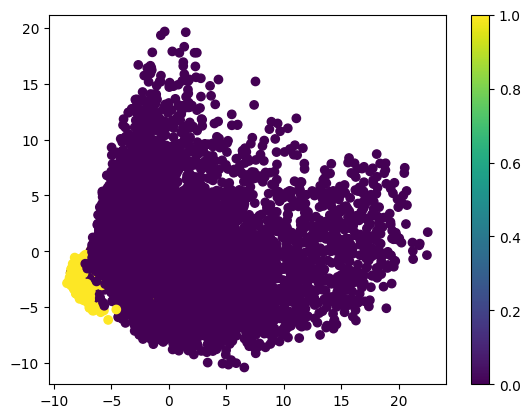

In [19]:
plt.scatter(x1, x2, c=y)
plt.colorbar()
plt.show()

Damit darf ich Ihnen gratulieren. Sie haben eine beliebte Methode aus dem Methodenarsenal des *Unsupervised Learning* selbst implementiert, die in verschiedenen Kontexten häufig zum Einsatz kommt! Lesen Sie zum Abschluss noch folgende ROT-13 kodierte Nachricht:

* Jraa Fvr rvazny iretyrvpura, jrypura Mrvgnhsjnaq Fvr orvz uäaqvfpura Srngher-Ratvarrevat va Üohat 4.3 rvatrfrgmg unora, hz unyojrtf gnhtyvpur Srngherf mh trarevrera, haq jvr fpuaryy Fvr arhr Srngherf qhepu CPN remrhtra xbaagra, zvg qrara Fvr rvar oenhpuoner Geraaonexrvg qre rvara Xynffr (Rvafra) iba qre naqrera Xynffr (erfgyvpur Mvssrea) remvryra xbaagr, qnaa irefgrura Fvr irezhgyvpu qvr Nggenxgvivgäg iba fpuaryyra Hafhcreivfrq Yrneavat Zrgubqra. Qvr CPN mäuyg nhpu mh qra Qvzrafvbaferqhxgvbafgrpuavxra, qvr trrvtarg vfg, hz yvarner Fgehxghera nhf uöureqvzrafvbanyra Eähzra mh rkgenuvrera. Rf rkvfgvrera qvirefr Zrgubqra, hz qvrf nhpu süe avpugyvarner Fgehxghera mh remvryra, haq qvrf vfg rvar nxghryyr Sbefpuhatfevpughat.

(11) \[Optional\] Visualisieren Sie die kumulative *Proportion of Variance Explained* (PVE) als Funktion der PCA-Komponenten.

* Wie viel Prozent der Gesamtvarianz der Daten werden durch die ersten beiden PCA-Komponenten repräsentiert?

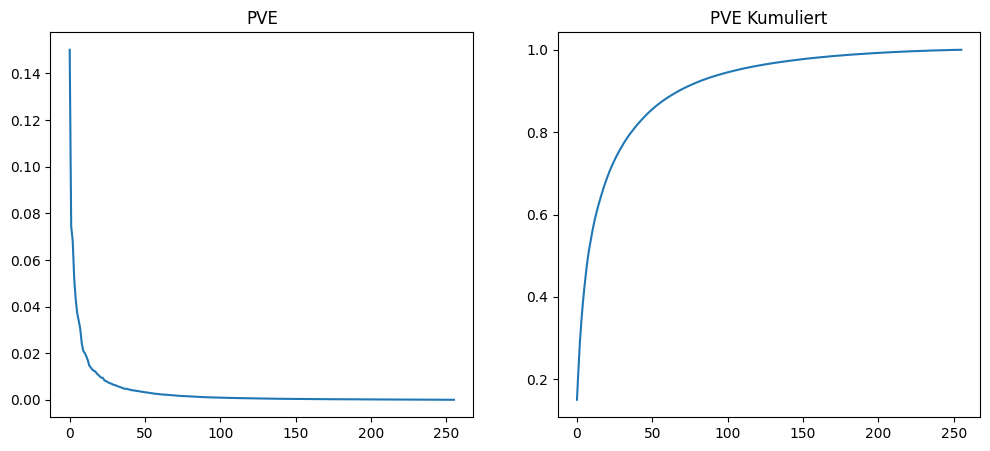

In [20]:
pve = eigvals / eigvals.sum()
pve_cumulated = pve.cumsum()
_, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(pve)
ax[0].set_title("PVE")
ax[1].plot(pve_cumulated)
ax[1].set_title("PVE Kumuliert")
plt.show()

In [21]:
print(f"Es werden {pve_cumulated[1] * 100} % der Gesamtvarianz durch die ersten beiden PCA Komponenten repräsentiert.")

Es werden 22.456963799086154 % der Gesamtvarianz durch die ersten beiden PCA Komponenten repräsentiert.


(12) \[Optional\] Visualisieren Sie *Proportion of Variance Explained* (PVE) als Funktion der PCA-Komponenten. PCA wird häufig als Dimensionsreduktionsmethode eingesetzt, die die Anzahl der Features reduziert. Wie viele PCA-Komponenten würden Sie einsetzen, um die Daten mit weniger Features zu repräsentieren? Betrachten Sie dazu Ihre Abbildung und argumentieren Sie mit der PVE.

Ich würde direkt noch dem Ellbogen der PVE, also etwa bei 50 Dimensionen einen Schnitt setzen.

In [22]:
print(f"Damit würden {pve_cumulated[50] * 100} % der Gesamtvarianz abgebildet werden, wobei nur {50 / 2.56} % der Dimensionen gebraucht werden.")

Damit würden 85.57037714044085 % der Gesamtvarianz abgebildet werden, wobei nur 19.53125 % der Dimensionen gebraucht werden.


Wenn man sicher gehen will, kann man bei Komponente 100 schneiden.

In [23]:
print(f"Damit würden {pve_cumulated[100] * 100} % der Gesamtvarianz abgebildet werden, wobei nur {100 / 2.56} % der Dimensionen gebraucht werden.")

Damit würden 94.52670109829641 % der Gesamtvarianz abgebildet werden, wobei nur 39.0625 % der Dimensionen gebraucht werden.


(13) \[Optional\] Nutzen Sie die Features `x1` und `x2` aus Schritt (9) und trainieren Sie ein Perzeptron mithilfe des Pocket Algorithmus für mehrere tausend Schritte. Schätzen Sie den Out-of-Sample Fehler $E_\text{out}$ auf dem Testdatensatz (den Sie vorher in die vom Trainingsset bereitgestellten PCA-Komponenten transformiert haben) und geben Sie ihn an. Vergleichen Sie den Out-of-Sample Fehler mit demjenigen, den Sie in Aufgabe 4.3 für Ihre eigenen Features erzielt hatten. Welche Features, die PCA-Features oder Ihre Features aus Aufgabe 4.3, führen zu einem kleineren Out-of-Sample Fehler?


In [24]:
y = np.where(data["train_targets"] == 1, 1, -1)[0]
y_test = np.where(data["test_targets"] == 1, 1, -1)[0]
print(y.shape, y_test.shape)

(7291,) (2007,)


In [25]:
def h(x: np.ndarray, w: np.ndarray):
    return np.sign(x.dot(w))


def g(x_1, w):
    return (w[0] + w[1] * x_1) / (-w[2])


def pla_pocket(x: np.ndarray, y: np.ndarray, iterations: int):
    x_stacked = np.hstack((np.ones(((x.shape[0], 1))), x))
    w_best = np.zeros(x_stacked.shape[1])
    w_curr = w_best.copy()
    bools_curr = h(x_stacked, w_best) != y
    err = np.sum(bools_curr) / bools_curr.shape[0]
    i = 0
    while i < iterations and err > 0:
        idx = np.random.choice(np.arange(bools_curr.sum()), 1)[0]

        x_k = x_stacked[bools_curr][idx]
        y_k = y[bools_curr][idx]
        w_curr = w_curr + y_k * x_k
        bools_curr = h(x_stacked, w_curr) != y
        err_temp = np.sum(bools_curr) / bools_curr.shape[0]
        if err_temp < err:
            w_best = w_curr.copy()
            err = err_temp
        i += 1
    return w_best

In [26]:
%%time
w_pca = pla_pocket(np.c_[x1, x2], y, 10000)

CPU times: total: 797 ms
Wall time: 801 ms


In [27]:
X_test_scored = zscore(data["test_data"])
x1_test = X_test_scored @ eigvecs[:, 0]
x2_test = X_test_scored @ eigvecs[:, 1]

In [28]:
y_pred_pca = h(np.c_[np.ones(x1_test.shape), x1_test, x2_test], w_pca)
e_out = (y_pred_pca != y_test).sum() / len(y_test)

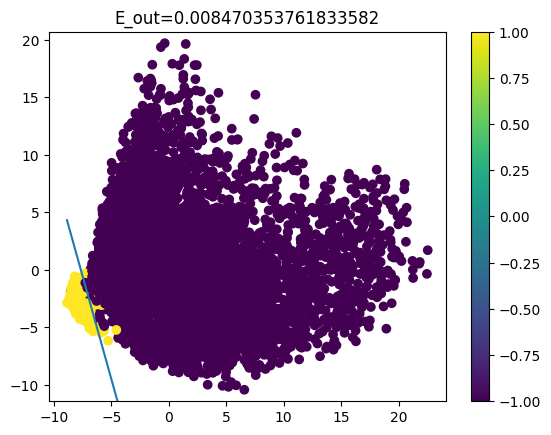

In [29]:
number_pca_xspace = np.linspace(x1.min(), x1.max())

plt.scatter(x1, x2, c=y)
plt.plot(number_pca_xspace, g(number_pca_xspace, w_pca))
plt.colorbar()
plt.ylim((x2.min()-1, x2.max()+1))
plt.title(f"E_out={e_out}")
plt.show()

In [30]:
X: np.ndarray = data['train_data']
# Anz der Schwarzen Pixel
sum_of_values = X.sum(axis=1)

# Anz der gleichen Pixel, wenn das Bild in dev Diagonalen gespiegelt wird
vertical_symetricity = (X.reshape((X.shape[0], 16, 16)) == np.flip(X.reshape((X.shape[0], 16, 16)).copy(), 1)).reshape(X.shape[0], X.shape[1]).sum(axis=1)


x_train_4_3 = zscore(np.c_[sum_of_values, vertical_symetricity])

In [31]:
X_test: np.ndarray = data['test_data']
# Anz der Schwarzen Pixel
sum_of_values_test = X_test.sum(axis=1)

# Anz der gleichen Pixel, wenn das Bild in dev Diagonalen gespiegelt wird
vertical_symetricity_test = (X_test.reshape((X_test.shape[0], 16, 16)) == np.flip(X_test.reshape((X_test.shape[0], 16, 16)).copy(), 1)).reshape(X_test.shape[0], X_test.shape[1]).sum(axis=1)


x_test_4_3 = zscore(np.c_[sum_of_values_test, vertical_symetricity_test])
x_test_4_3_stacked = np.hstack((np.ones(((x_test_4_3.shape[0], 1))), x_test_4_3))

In [32]:
%%time
w_4_3 = pla_pocket(x_train_4_3, y, 10000)

CPU times: total: 781 ms
Wall time: 771 ms


In [33]:
y_pred_4_3 = h(x_test_4_3_stacked, w_4_3)
e_out = (y_pred_4_3 != y_test).sum() / len(y_test)

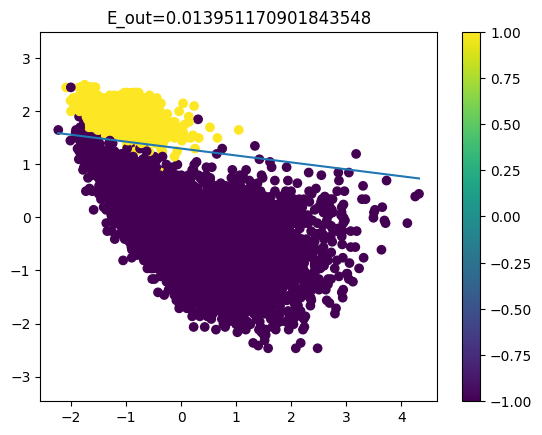

In [34]:
number_4_3_xspace = np.linspace(x_train_4_3[:, 0].min(), x_train_4_3[:, 0].max())

plt.scatter(x_train_4_3[:, 0], x_train_4_3[:, 1], c=y)
plt.plot(number_4_3_xspace, g(number_4_3_xspace, w_4_3))
plt.colorbar()
plt.ylim((x_train_4_3[:, 1].min()-1, x_train_4_3[:, 1].max()+1))
plt.title(f"E_out={e_out}")
plt.show()

Ergebnis: Die Zwei PCA Achsen sorgen für einen besseren Out of Sample Fehler auf den Daten und somit wahrscheinlich für einen geringeren Informationsverlust.

In [35]:
x_tranformed_50 = X_scored @ eigvecs[:, :50]
print(X_scored.shape)
print(x_tranformed_50.shape)

(7291, 256)
(7291, 50)


In [36]:
%%time
w_pca_50 = pla_pocket(x_tranformed_50, y, 100000)

CPU times: total: 13.3 s
Wall time: 13.4 s


In [37]:
x_test_transformed_50 = X_test_scored @ eigvecs[:, :50]
x_test_pca_50_stacked = np.hstack((np.ones(((x_test_transformed_50.shape[0], 1))), x_test_transformed_50))
y_pred_pca_50 = h(x_test_pca_50_stacked, w_pca_50)
print(f"E_out = {(y_pred_pca_50 != y_test).sum() / len(y_test)}")

E_out = 0.008470353761833582


In [38]:
x_tranformed_100 = X_scored @ eigvecs[:, :100]
print(X_scored.shape)
print(x_tranformed_100.shape)

(7291, 256)
(7291, 100)


In [39]:
%%time
w_pca_100 = pla_pocket(x_tranformed_100, y, 100000)

CPU times: total: 41.2 s
Wall time: 28.2 s


In [40]:
x_test_transformed_100 = X_test_scored @ eigvecs[:, :100]
x_test_pca_100_stacked = np.hstack((np.ones(((x_test_transformed_100.shape[0], 1))), x_test_transformed_100))
y_pred_pca_100 = h(x_test_pca_100_stacked, w_pca_100)
print(f"E_out = {(y_pred_pca_100 != y_test).sum() / len(y_test)}")

E_out = 0.013452914798206279


Erhöhen der PCA Komponenten verbessert nicht immer den Out of sample Fehler